In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

with fits.open('Planet_Lightcurve.fits') as hdul:
    data = hdul[1].data
    time = data['time [days]']          
    raw_flux = data['flux    ']      

# replace with flux with no noise later
cleaned_flux = raw_flux  

In [10]:
def calculate_transit_properties(time_array, flux_array, r_star=1.0):
    """
    Estimates the transit depth (D), transit length (duration), and 
    the exoplanet's radius (R_planet) based on relative flux data.
    """
    baseline_flux = 1.0 
    
    min_flux = np.min(flux_array)
    transit_depth = baseline_flux - min_flux
    
    threshold = baseline_flux - (0.3 * transit_depth)
    transit_indices = np.where(flux_array < threshold)[0]
    
    if len(transit_indices) > 0:
        start_time = time_array[transit_indices[0]]
        end_time = time_array[transit_indices[-1]]
        transit_length = end_time - start_time
    else:
        transit_length = 0.0
        print("Warning: No transit detected with the current threshold.")
        transit_indices = [0, 0]

    if transit_depth > 0:
        r_planet = r_star * np.sqrt(transit_depth)
    else:
        r_planet = 0.0
        print("Warning: Calculated transit depth is zero or negative.")
        
    return {
        "depth": transit_depth,
        "length_days": transit_length,
        "r_planet_solar": r_planet,
        "window_indices": (transit_indices[0], transit_indices[-1])
    }

In [20]:
results = calculate_transit_properties(time, cleaned_flux, r_star=1.0)

print("STEP 3 ANALYSIS RESULTS:")
print(f"Transit Depth (D):       {results['depth']:.5f} (relative flux)")
print(f"Transit Length:          {results['length_days']:.4f} days")
print(f"Estimated Planet Radius: {results['r_planet_solar']:.4f} Solar Radii")

STEP 3 ANALYSIS RESULTS:
Transit Depth (D):       0.03475 (relative flux)
Transit Length:          0.5387 days
Estimated Planet Radius: 0.1864 Solar Radii


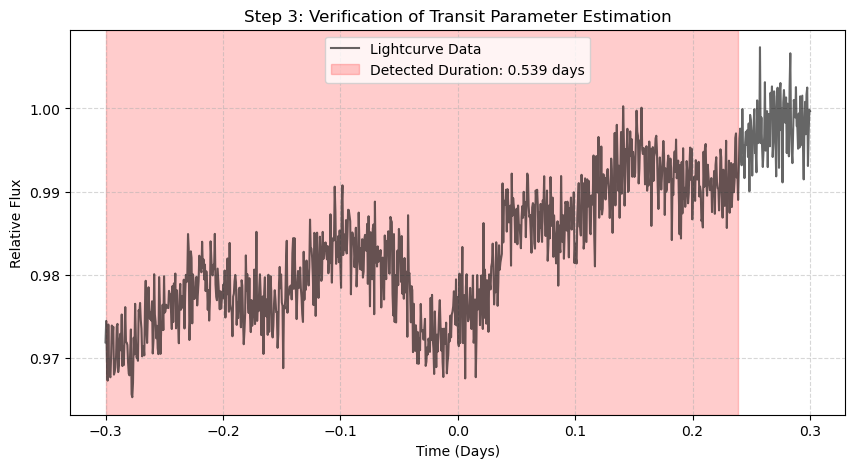

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(time, cleaned_flux, label='Lightcurve Data', color='black', alpha=0.6)

idx_start, idx_end = results['window_indices']
plt.axvspan(time[idx_start], time[idx_end], color='red', alpha=0.2, 
            label=f"Detected Duration: {results['length_days']:.3f} days")

plt.xlabel('Time (Days)')
plt.ylabel('Relative Flux')
plt.title('Step 3: Verification of Transit Parameter Estimation')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('step3.png')
plt.show()